# MSCS 634 Project Deliverable 1

## Data Collection, Cleaning, and Exploration

**Authors:** Asha Kilaru and Venkatappareddy Monukonda



### Step 1: Dataset Selection and Motivation

The dataset selected for this project is the CMS Medicare Quarterly Part B Spending by Drug dataset published by the Centers for Medicare & Medicaid Services (CMS). It contains information on Medicare Part B drug utilization and spending, including the number of beneficiaries, total claims, total spending, average spending per beneficiary, average spending per claim, drug identifiers, and reporting year. The dataset includes both numerical and categorical variables, making it appropriate for data cleaning, exploratory analysis, feature engineering, and predictive modeling.

This dataset was selected because it represents real healthcare spending patterns and provides sufficient observations and attribute diversity for data mining tasks. Since Medicare spending is influenced by several utilization measures, the dataset offers meaningful opportunities to explore relationships among variables and build regression models that predict healthcare spending in later stages of the project.

In [3]:
import json
import re
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load the dataset directly from the CMS data API
url = "https://data.cms.gov/data-api/v1/dataset/bf6a5b3b-31ee-4abb-b1ad-2607a1e7510a/data"
req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0", "Accept": "application/json"})
with urllib.request.urlopen(req, timeout=120) as response:
    raw_data = json.load(response)

df = pd.DataFrame(raw_data)
print("Dataset loaded successfully.")
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("\nFirst 5 rows:")
display(df.head())
print("\nDataset Information")
df.info()

print("\nSummary Statistics")
display(df.describe(include="all"))

Dataset loaded successfully.
Shape: (1000, 10)
Columns: ['Brnd_Name', 'Gnrc_Name', 'HCPCS_Cd', 'HCPCS_Desc', 'Year', 'Tot_Benes', 'Tot_Clms', 'Tot_Spndng', 'Avg_Spnd_Per_Bene', 'Avg_Spnd_Per_Clm']

First 5 rows:


,Brnd_Name,Gnrc_Name,HCPCS_Cd,HCPCS_Desc,Year,Tot_Benes,Tot_Clms,Tot_Spndng,Avg_Spnd_Per_Bene,Avg_Spnd_Per_Clm
0,HYPERHEP B*,HEPATITIS B IMMUNE GLOBULIN*,90371,HEP B IG IM,2025 (Q1-Q4),42,82,58578.82,1394.7338095,714.37585366
1,HYPERHEP B*,HEPATITIS B IMMUNE GLOBULIN*,90371,HEP B IG IM,2026 (Q1),19,28,24281.06,1277.9505263,867.18071429
2,HYPERRAB,RABIES IMMUNE GLOBULIN,90375,RABIES IG IM/SC,2025 (Q1-Q4),4205,4219,11965232.66,2845.4774459,2836.0352358
3,HYPERRAB,RABIES IMMUNE GLOBULIN,90375,RABIES IG IM/SC,2026 (Q1),681,686,2000953.12,2938.2571512,2916.8412828
4,KEDRAB,RABIES IMMUNE GLOBULIN,90377,RABIES IG HT&SOL HUMAN IM/SC,2025 (Q1-Q4),1271,1273,3020777.33,2376.6934146,2372.9594108


Before performing any preprocessing, the overall structure of the dataset was examined to understand the available variables, identify data types, detect missing values, and review the statistical characteristics of both numerical and categorical attributes. This preliminary assessment helps determine the most appropriate data cleaning strategy.

### Step 2: Data Cleaning and Preparation

This step prepares the dataset for analysis by verifying data quality and ensuring that the variables are in an appropriate format for analysis. The process includes checking data types, identifying missing values and duplicate records, standardizing numerical variables, and detecting potential outliers that may influence future modeling.

In [7]:
# Review data types and missing values before cleaning
print(df.dtypes)
print("\nMissing values before cleaning:")
print(df.isna().sum())
print("\nRows before cleaning:", len(df))
print("Duplicate rows:", df.duplicated().sum())

# Convert numeric columns to numeric type
numeric_cols = ["Tot_Benes", "Tot_Clms", "Tot_Spndng", "Avg_Spnd_Per_Bene", "Avg_Spnd_Per_Clm"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove duplicate rows
duplicates = df.duplicated().sum()
print(f"Duplicate rows before removal: {duplicates}")

df = df.drop_duplicates()

print(f"Rows after duplicate removal: {df.shape[0]}")

# Drop rows that are completely empty
df = df.dropna(how="all")

# Fill missing values for categorical columns with a placeholder
categorical_fill = ["Brnd_Name", "Gnrc_Name", "HCPCS_Cd", "HCPCS_Desc", "Year"]
for col in categorical_fill:
    df[col] = df[col].fillna("Unknown")

# Fill missing numeric values with the median of the column
for col in numeric_cols:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)
    
print("Rows before cleaning:", len(df))

# Clean the Year column by extracting the year from values such as 2025 (Q1-Q4)
def extract_year(value):
    if pd.isna(value):
        return np.nan
    text = str(value)
    match = re.search(r"(\d{4})", text)
    return int(match.group(1)) if match else np.nan

print("Rows after cleaning:", len(df))

df["Year_Value"] = df["Year"].apply(extract_year)
df["Year_Value"] = df["Year_Value"].fillna(df["Year_Value"].median())

# Identify possible outliers in total spending using the IQR rule
q1 = df["Tot_Spndng"].quantile(0.25)
q3 = df["Tot_Spndng"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outlier_count = ((df["Tot_Spndng"] < lower_bound) | (df["Tot_Spndng"] > upper_bound)).sum()

print("\nMissing values after cleaning:")
print(df.isna().sum())
print("\nRows after cleaning:", df.shape[0])
print("Outlier rows for total spending:", outlier_count)

# Save a cleaned version for future use
df.to_csv("cms_healthcare_claims_cleaned.csv", index=False)
print("Cleaned data written to cms_healthcare_claims_cleaned.csv")

Brnd_Name             object
Gnrc_Name             object
HCPCS_Cd              object
HCPCS_Desc            object
Year                  object
Tot_Benes            float64
Tot_Clms               int64
Tot_Spndng           float64
Avg_Spnd_Per_Bene    float64
Avg_Spnd_Per_Clm     float64
Year_Value             int64
dtype: object

Missing values before cleaning:
Brnd_Name            0
Gnrc_Name            0
HCPCS_Cd             0
HCPCS_Desc           0
Year                 0
Tot_Benes            0
Tot_Clms             0
Tot_Spndng           0
Avg_Spnd_Per_Bene    0
Avg_Spnd_Per_Clm     0
Year_Value           0
dtype: int64

Rows before cleaning: 1000
Duplicate rows: 0
Duplicate rows before removal: 0
Rows after duplicate removal: 1000
Rows before cleaning: 1000
Rows after cleaning: 1000

Missing values after cleaning:
Brnd_Name            0
Gnrc_Name            0
HCPCS_Cd             0
HCPCS_Desc           0
Year                 0
Tot_Benes            0
Tot_Clms             0
Tot_Spnd

#### Discussion

The initial inspection showed that all variables were successfully loaded from the CMS API. Because the numerical variables were imported as text, they were converted into numeric data types so they could be used for statistical analysis and predictive modeling.

The data quality assessment showed that the dataset contained no missing values or duplicate records, indicating that the published CMS data was already well maintained. Although no missing values required imputation, the cleaning workflow retained those steps to ensure the notebook can be reused if future versions of the dataset contain incomplete records.

The reporting year was converted into a new numerical feature (Year_Value), making it easier to use in later analysis and regression models. The IQR method identified 171 observations with unusually high total spending. These observations were retained because high Medicare spending often represents legitimate high-cost drugs rather than data entry errors. Keeping these records preserves the real characteristics of the dataset while acknowledging that extreme values may influence future models.

Finally, the cleaned dataset was saved as a separate CSV file so that the same processed data can be used consistently throughout the remaining project deliverables.

### Step 3: Exploratory Data Analysis

This step explores the main characteristics of the CMS Medicare Part B Spending by Drug dataset using visualizations. The objective is to understand how Medicare spending is distributed, identify the highest-spending drugs, examine the relationship between claim volume and spending, and observe spending trends over time. These visualizations help identify important patterns before developing predictive models.

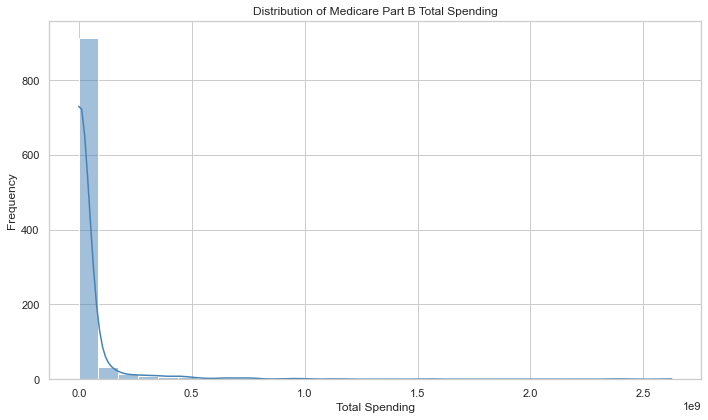

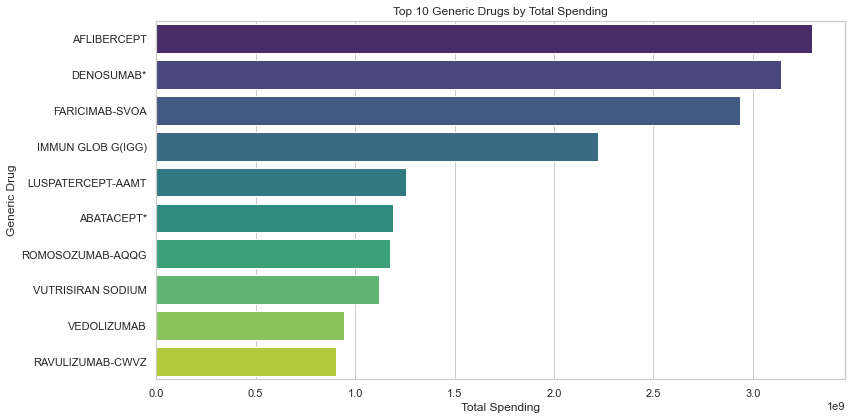

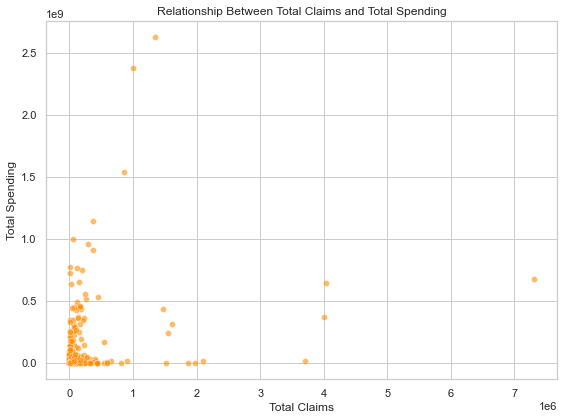

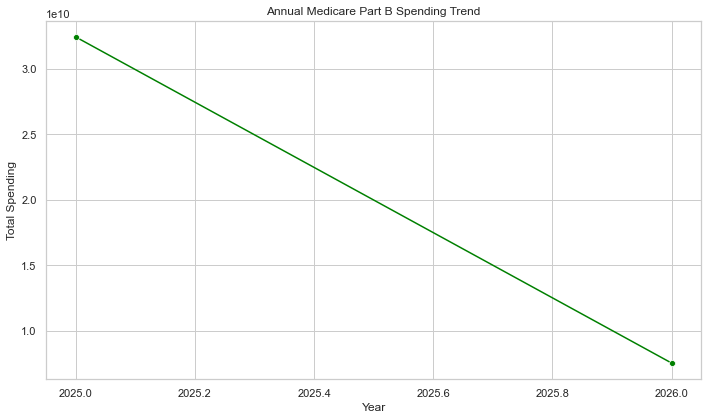

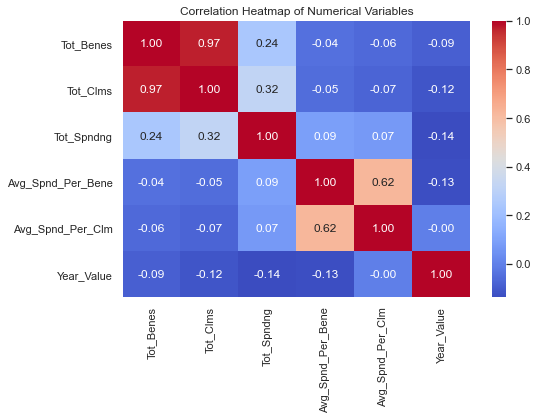

In [9]:
# Distribution of total spending
plt.figure(figsize=(10, 6))
sns.histplot(df["Tot_Spndng"], bins=30, kde=True, color="steelblue")
plt.title("Distribution of Medicare Part B Total Spending")
plt.xlabel("Total Spending")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Top 10 generic drugs by total spending
top_generic = df.groupby("Gnrc_Name")["Tot_Spndng"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_generic.values, y=top_generic.index, palette="viridis")
plt.title("Top 10 Generic Drugs by Total Spending")
plt.xlabel("Total Spending")
plt.ylabel("Generic Drug")
plt.tight_layout()
plt.show()

# Relationship between claims and spending
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Tot_Clms", y="Tot_Spndng", alpha=0.6, color="darkorange")
plt.title("Relationship Between Total Claims and Total Spending")
plt.xlabel("Total Claims")
plt.ylabel("Total Spending")
plt.tight_layout()
plt.show()

# Yearly spending trend
yearly_spending = df.groupby("Year_Value")["Tot_Spndng"].sum().sort_index()

plt.figure(figsize=(10, 6))
sns.lineplot(x=yearly_spending.index, y=yearly_spending.values, marker="o", color="green")
plt.title("Annual Medicare Part B Spending Trend")
plt.xlabel("Year")
plt.ylabel("Total Spending")
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(8,6))

corr = df[numeric_cols + ["Year_Value"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()

#### Discussion

The histogram showed that Medicare spending is highly right-skewed, meaning that many drugs account for relatively lower spending while a smaller number contribute substantially higher Medicare expenditures. This pattern is consistent with the outliers identified during data cleaning and reflects the presence of high-cost medications.

The bar chart showed that total Medicare spending is concentrated among a relatively small number of generic drugs. This suggests that certain medications have a much greater financial impact on the Medicare program than others.

The scatter plot showed a positive relationship between total claims and total spending. Although the relationship is not perfectly linear, drugs with higher claim volumes generally tend to generate greater Medicare spending. This indicates that claim volume is likely to be an important predictor in future regression models.

The yearly spending trend provides additional context by illustrating how overall Medicare spending changes across reporting periods. The correlation heatmap complements these visualizations by summarizing the relationships among the numerical variables, helping identify variables that may contribute useful information during feature selection and model development.

### Step 4: Insights and Future Modeling Direction

The exploratory analysis showed that the CMS Medicare Part B Spending by Drug dataset is well suited for predictive modeling after preprocessing. The data quality assessment confirmed that the dataset contained no missing values or duplicate records, while converting numerical variables and creating the Year_Value feature improved its readiness for analysis.

The visualizations showed that total Medicare spending is highly right-skewed, indicating that a relatively small number of drugs account for a large share of overall spending. The scatter plot also showed a positive relationship between total claims and total spending, suggesting that utilization measures are likely to be useful predictors in regression models. The correlation analysis further highlighted relationships among the numerical variables, providing additional guidance for feature selection.

These findings will support the next phase of the project by helping identify meaningful predictor variables and informing feature engineering decisions. The cleaned dataset and the insights gained from the exploratory analysis provide a solid foundation for developing and evaluating regression models in Deliverable 2.